# 4. 그림자 캡슐 생성 + 시간 입력 함수화

## 1) import & 데이터 로드

In [46]:
from pathlib import Path
import math, pickle, datetime
import numpy as np
import pandas as pd
import pytz
from pysolar.solar import get_altitude, get_azimuth

In [47]:
ARTIFACTS_DIR = Path(r"C:\Users\1\Desktop\proj. SENA\공모전\대구 빅데이터 분석대회\artifacts")

with open(ARTIFACTS_DIR / "graph_xy.pkl", "rb") as f:
    G = pickle.load(f)

buildings = pd.read_parquet(ARTIFACTS_DIR / "buildings_xy.parquet").copy()

In [48]:
len(buildings)

116

In [49]:
# 안전: 타입 보정
for col in ["lat","lng","height","radius","x","y"]:
    if col in buildings.columns:
        buildings[col] = pd.to_numeric(buildings[col], errors="coerce")
buildings = buildings.dropna(subset=["lat","lng","height","radius","x","y"]).reset_index(drop=True)

print("노드/간선/건물:", G.number_of_nodes(), G.number_of_edges(), len(buildings))

노드/간선/건물: 330 440 87


## 2) 시간 유틸 & 태양벡터 유틸

In [50]:
KST = pytz.timezone("Asia/Seoul")

In [51]:
# datetime 객체가 반드시 한국 표준시 타임존 가지도록 보장하는 역할
def ensure_tz_kst(dt_local: datetime.datetime) -> datetime.datetime:
    """tz-aware KST datetime 보장 (naive면 KST로 로컬라이즈)."""
    if dt_local.tzinfo is None:
        return KST.localize(dt_local)
    return dt_local.astimezone(KST)

UTC = Coordinated Universal Time (협정 세계시)

In [52]:
# 한국 시각으로 주어진 시각을 UTC()로 변환
def to_utc(dt_local: datetime.datetime) -> datetime.datetime:
    dt_local = ensure_tz_kst(dt_local) # KST로 보정
    return dt_local.astimezone(pytz.UTC)

In [53]:
# "태양의 방위각을 ENU 평면 좌표계(x=동, y=북) 단위벡터로 변환"하는 함수.
def azimuth_deg_to_unit_xy(az_deg: float):
    """
    Pysolar: 0°=북, 시계방향(동=90, 남=180, 서=270).
    ENU(x=동, y=북) 기준 태양 방향 단위벡터.
    """
    th = math.radians(az_deg)
    ux = math.sin(th)  # East
    uy = math.cos(th)  # North
    return ux, uy

In [54]:
# test
print(azimuth_deg_to_unit_xy(0))     # 북쪽 → (0, 1)
print(azimuth_deg_to_unit_xy(90))    # 동쪽 → (1, 0)
print(azimuth_deg_to_unit_xy(180))   # 남쪽 → (0, -1)
print(azimuth_deg_to_unit_xy(270))   # 서쪽 → (-1, 0)

(0.0, 1.0)
(1.0, 6.123233995736766e-17)
(1.2246467991473532e-16, -1.0)
(-1.0, -1.8369701987210297e-16)


## 3) “직사각형 그림자” 데이터 구조 & 생성 함수

* 폭 = 2 * radius
* 길이 = L = height / tan(alt) (alt ≤ 0이면 그림자 없음)
* 방향 = 태양 방위각의 반대 (단위벡터 (-ux, -uy))
* 직사각형 4꼭짓점은 중심선(길이 L) 과 법선(폭/2) 로 계산*

In [55]:
from dataclasses import dataclass
from typing import List, Dict, Any, Tuple
import math
import pandas as pd
import datetime
import pytz
from pysolar.solar import get_altitude, get_azimuth

In [56]:
@dataclass
class ShadowRect:
    cx: float      # 직사각형 중심 x  (center = c + (L/2)·d)
    cy: float      # 직사각형 중심 y
    length: float  # L
    width: float   # 2r
    dx: float      # d_x (태양 반대 단위벡터)
    dy: float      # d_y
    meta: Dict[str, Any]

    def endpoints(self) -> Tuple[Tuple[float,float], Tuple[float,float]]:
        """중심선 양끝점 (start, end). start는 건물 중심 c, end는 c + L·d와 거의 일치."""
        hx = 0.5 * self.length * self.dx
        hy = 0.5 * self.length * self.dy
        # 중심선 = [center - (L/2)d, center + (L/2)d]
        return (self.cx - hx, self.cy - hy), (self.cx + hx, self.cy + hy)

    def corners(self) -> List[Tuple[float, float]]:
        """
        직사각형 꼭짓점 4개를 시계방향으로 반환.
        길이 방향 단위벡터 = (dx,dy), 폭 방향 법선 = (-dy, dx).
        """
        hx = 0.5 * self.length * self.dx
        hy = 0.5 * self.length * self.dy
        nx, ny = -self.dy, self.dx
        half_w = 0.5 * self.width

        c1x, c1y = self.cx - hx, self.cy - hy   # 중심선 시작(건물 중심 쪽)
        c2x, c2y = self.cx + hx, self.cy + hy   # 중심선 끝(그림자 끝)

        p1 = (c1x - half_w*nx, c1y - half_w*ny)
        p2 = (c1x + half_w*nx, c1y + half_w*ny)
        p3 = (c2x + half_w*nx, c2y + half_w*ny)
        p4 = (c2x - half_w*nx, c2y - half_w*ny)
        return [p1, p2, p3, p4]

In [57]:
def build_shadow_rects(buildings_df: pd.DataFrame, dt_local: datetime.datetime):
    """
    정확 모델:
      - 끝점 = c + L·d  (c=건물 중심, d=태양 반대 단위벡터)
      - 중심 = c + (L/2)·d
      - 폭   = 2r
      - 시작(건물 중심)에서 한쪽으로만 뻗는 직사각형
    입력 필요 컬럼: lat,lng,x,y,height,radius
    """
    dt_utc = to_utc(dt_local)
    out = buildings_df.copy()

    out["sun_alt_deg"]  = 0.0
    out["sun_az_deg"]   = 0.0
    out["shadow_len_m"] = 0.0
    out["shadow_dir_x"] = 0.0
    out["shadow_dir_y"] = 0.0

    rects: List[ShadowRect] = []

    # (옵션) 건물명 컬럼 추정
    name_col = None
    for c in out.columns:
        if c.lower() in ["name", "building_name", "건물명", "dong_num"]:
            name_col = c; break

    for idx, row in out.iterrows():
        lat = float(row["lat"]); lng = float(row["lng"])
        alt = get_altitude(lat, lng, dt_utc)  # 고도(°)
        az  = get_azimuth(lat, lng, dt_utc)  # 방위각(°)

        out.at[idx, "sun_alt_deg"] = alt
        out.at[idx, "sun_az_deg"]  = az

        if alt <= 0:     # 밤/지평선 아래 → 그림자 없음
            continue

        # 1) 그림자 길이
        L = float(row["height"]) / math.tan(math.radians(alt))

        # 2) 태양 반대 방향 단위벡터 d
        ux, uy = azimuth_deg_to_unit_xy(az)  # 태양 '쪽'
        dx, dy = -ux, -uy                    # 그림자 방향(반대쪽)
        nrm = math.hypot(dx, dy)
        if nrm == 0:
            continue
        dx, dy = dx/nrm, dy/nrm

        # 3) 직사각형 중심 = c + (L/2)·d
        cx0, cy0 = float(row["x"]), float(row["y"])
        cx = cx0 + 0.5 * L * dx
        cy = cy0 + 0.5 * L * dy

        # 4) 폭 = 2r
        r = float(row["radius"])
        width = 2.0 * r

        # 메타/출력 갱신
        out.at[idx, "shadow_len_m"] = L
        out.at[idx, "shadow_dir_x"] = dx
        out.at[idx, "shadow_dir_y"] = dy

        meta = {"name": (row[name_col] if name_col else None),
                "alt_deg": alt, "az_deg": az,
                "building_center": (cx0, cy0)}

        rects.append(ShadowRect(cx=cx, cy=cy, length=L, width=width, dx=dx, dy=dy, meta=meta))

    return out, rects

## 4) 실행 테스트

In [58]:
import pickle
from pathlib import Path

오늘 낮 시간으로 테스트

In [59]:
# 입력 테이블 타입 보정(안전)
for col in ["lat","lng","height","radius","x","y"]:
    if col in buildings.columns:
        buildings[col] = pd.to_numeric(buildings[col], errors="coerce")
buildings = buildings.dropna(subset=["lat","lng","height","radius","x","y"]).reset_index(drop=True)

today = datetime.date.today()
# 오늘 날짜의 13시(KST)로 지정
test_time = datetime.datetime(today.year, today.month, today.day, 13, 0, 0, tzinfo=KST)

b_with_sun, shadow_rects = build_shadow_rects(buildings, test_time)

print("직사각형 그림자 생성 수(낮 건물 수):", len(shadow_rects), "/", len(b_with_sun))
print("그림자 길이 통계(낮만):", b_with_sun.loc[b_with_sun["shadow_len_m"]>0, "shadow_len_m"].describe().to_dict())

# 샘플 하나 확인
print("샘플 직사각형 corner 4점:", shadow_rects[0].corners() if shadow_rects else None)

직사각형 그림자 생성 수(낮 건물 수): 87 / 87
그림자 길이 통계(낮만): {'count': 87.0, 'mean': 12.855255885192266, 'std': 7.0360387021337285, 'min': 2.6044398866406717, '25%': 8.910718914122842, '50%': 12.263574379820689, '75%': 15.925108265413824, 'max': 51.8309972583074}
샘플 직사각형 corner 4점: [(-329.0547013369537, -250.6470875799946), (-364.0187093672441, -228.89496342175704), (-356.9488408282841, -217.530972550287), (-321.9848327979937, -239.28309670852457)]


## 5) 시각화 확인 (선 중심선 + 직사각형 외각선)

샘플 일부만

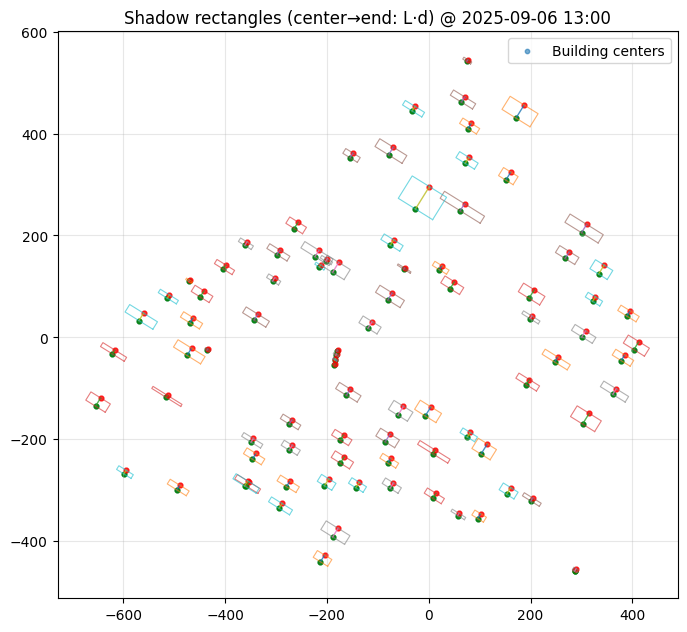

In [60]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,8))

# (1) 건물 중심점 (c)
ax.scatter(buildings["x"], buildings["y"], s=10, alpha=0.6, label="Building centers")

for r in shadow_rects:
    # 2-1) 중심선 양끝점 계산
    (x_start, y_start), (x_end, y_end) = r.endpoints()

    # 2-2) 중심선 그리기 (건물 중심→끝점 한쪽 방향)
    ax.plot([x_start, x_end], [y_start, y_end], lw=1, alpha=0.8, label=None)

    # 2-3) 직사각형 윤곽
    pts = r.corners()
    xs = [p[0] for p in pts] + [pts[0][0]]
    ys = [p[1] for p in pts] + [pts[0][1]]
    ax.plot(xs, ys, lw=0.8, alpha=0.6, label=None)

    # 2-4) 검증: 건물 중심 c 표시(초록점) & 이론적 끝점 표시(빨간점)
    cx0, cy0 = r.meta["building_center"]
    ax.scatter([cx0], [cy0], s=12, color="green", alpha=0.8)  # 중심 c
    # 이론적 끝점 end = c + L·d
    end_x = cx0 + r.length * r.dx
    end_y = cy0 + r.length * r.dy
    ax.scatter([end_x], [end_y], s=12, color="red", alpha=0.8)

ax.set_aspect("equal", adjustable="box")
title_dt = test_time if 'test_time' in globals() else now_kst
ax.set_title(f"Shadow rectangles (center→end: L·d) @ {title_dt:%Y-%m-%d %H:%M}")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

## 6) 저장

In [61]:
# 태양정보 포함한 건물 테이블
b_with_sun.to_parquet(ARTIFACTS_DIR / "buildings_with_sun.parquet", index=False)

# 직사각형 리스트 (pickle)
with open(ARTIFACTS_DIR / "shadow_rects.pkl", "wb") as f:
    pickle.dump(shadow_rects, f)

print("저장:", ARTIFACTS_DIR / "buildings_with_sun.parquet")
print("저장:", ARTIFACTS_DIR / "shadow_rects.pkl")


저장: C:\Users\1\Desktop\proj. SENA\공모전\대구 빅데이터 분석대회\artifacts\buildings_with_sun.parquet
저장: C:\Users\1\Desktop\proj. SENA\공모전\대구 빅데이터 분석대회\artifacts\shadow_rects.pkl
